In [ ]:
# Loading libraries, setting up datasets and dataloader
import sys

sys.path.append("/home/alberto/MONO3D")
from utilities import *
import yaml
import time
import json
import os

# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import projections as proj
import augmentation
from utilities import *
import engine
import losses as loss

nativeprint = print
from utilities import *
import dataset
import importlib
import torch
import torch.nn as nn
import random
import loggingutils as log
import networks.backbones as backbones
import networks.depth_decoding as depth_decoding
import cv2
from tqdm import tqdm
import torchinfo

importlib.reload(dataset)
# DATASET
BATCH_SIZE = 8
TRAIN_VAL_TEST_SPLIT = [0.7, 0.2, 0.1]
SHUFFLE = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DENSE_STACK = False
BACKBONE_PATCH_SIZE = 16
MAX_FRAMES = -1
NUM_WORKERS = 8
FRAMESKIP = []
COLOR_AUGMENTATION_PROB = 0.0
GEOM_AUGMENTATION_PROB = 0.0
IMAGE_HEIGHT = 384
IMAGE_WIDTH = 384
CURRICULUM_FACTOR = 0

TRAINING_VIDEOS_SCARED = [f"v{i}" for i in range(35)]  # dataset.scaredvideonames()
TRAINING_VIDEOS_STEREOMIS = []  # ["v1", "<v2", "v3", "v4", "v5", "v6", "v7", "v8","v9"]
VALIDATION_VIDEOS_SCARED = []  # "v20", "v21", "v22", "v23", "v24", "v25", "v26", "v27"]
VALIDATION_VIDEOS_STEREOMIS = []
TEST_VIDEOS_SCARED = ["v18", "v19"]
TEST_VIDEOS_STEREOMIS = ["v10"]

FPS_SCARED = 16
FPS_STEREOMIS = 1
FRAMESKIP_SCARED = [16]
FRAMESKIP_STEREOMIS = [1]
importlib.reload(dataset)
DATASET_ROOTDIR = os.environ["DATASET_ROOTDIR"]
DATASET_PATH_SCARED = os.path.join(DATASET_ROOTDIR, "SCARED")
DATASET_PATH_STEREOMIS = os.path.join(DATASET_ROOTDIR, "StereoMIS")
# Initializing training and validation datasets
ds = dataset.Mono3D_Dataset(
    path=DATASET_PATH_SCARED,
    vids=TRAINING_VIDEOS_SCARED,
    height=IMAGE_HEIGHT,
    width=IMAGE_WIDTH,
    frameskip=FRAMESKIP_SCARED,
    fps=FPS_SCARED,
    backbone_patch_size=BACKBONE_PATCH_SIZE,
    geometric_augmentation_prob=0.0,
    color_augmentation_prob=0.0,
    curriculum_factor=1,
    device=DEVICE,
    as_euler=True,
    with_fundamental=True,
    transforms_only=False,
    skip_order_check=True,
    with_frameskip=True,
    with_intrinsics=True,
    with_global_poses=False,
    unit_translation=False,
    with_paths=True,
    verbose=False,
    # as_embedding=True
)
####################z####################################################

training_ds = ds  # dataset.Dataset([ds])
training_dl = torch.utils.data.DataLoader(
    training_ds,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    sampler=training_ds.sampler,
)
training_dli = iter(training_dl)
sample = next(training_dli)
import networks.e2e_models as e2e
import networks.depth_decoding as depth_decoding
import networks.odometry_decoding as odometry_decoding
import networks.dfe as dfe
import networks
import projections as proj
import matching as match
import geometry
import losses as loss
import utilities.visualization as viz

importlib.reload(viz)
importlib.reload(depth_decoding)
importlib.reload(odometry_decoding)
importlib.reload(dfe)
importlib.reload(e2e)
importlib.reload(proj)
importlib.reload(match)
importlib.reload(networks.backbones)
importlib.reload(loss)

MODEL = e2e.MONO3D_E2E(backbone_brand="intel", size="large").to(DEVICE)
backProj = proj.BackProject(IMAGE_HEIGHT, IMAGE_WIDTH).to(DEVICE)
forwProj = proj.Project(IMAGE_HEIGHT, IMAGE_WIDTH).to(DEVICE)
Ffinder = proj.FundamentalEstimatorOpenCV()
loss_fn = loss.MONO3D_Loss(
    [
        (
            "Fundamental",
            loss.EpipolarLoss(),
            1.0,
            {
                "F_pred",
                "pts1",
                "pts2",
            },
        ),
        ("Odometry", loss.ScaleLoss(), 0.3, {"pose_pred", "pose_gt"}),
        (
            "Depth",
            loss.WeightedCombinationLoss(
                [
                    (
                        "Photometric",
                        loss.WeightedCombinationLoss(
                            [
                                (
                                    "SSIM",
                                    loss.SSIMLoss(),
                                    0.85,
                                    {"target", "warped"},
                                ),
                                (
                                    "L1",
                                    loss.L1Loss(),
                                    0.15,
                                    {"target", "warped"},
                                ),
                            ],
                            decay_config={"SSIM": 1e-4},
                        ),
                        1.0,
                        {"target", "warped"},
                    ),
                    (
                        "Edge",
                        loss.EASLoss(),
                        1.0,
                        {"warped", "depthmap"},
                    ),
                ],
                decay_config={"Photometric": 0.0},
            ),
            0.4,
            {"target", "warped", "depthmap"},
        ),
    ],
    decay_config={"Depth": 1e-3, "Odometry": -1e-5},
).to(DEVICE)
opt = torch.optim.Adam(MODEL.parameters(), lr=1e-4)
print("Dataset:", len(training_ds), "samples")
print(
    "Dataloader:",
    len(training_dl),
    "batches of shape",
    tuple(sample["framestack"].shape),
)
print(
    "MODEL"
    + "\n  ".join(
        [
            f"{name}: {sum(p.numel() for p in mod.parameters())} pms, requires_grad={any(p.requires_grad for p in mod.parameters())}"
            for name, mod in list(MODEL.named_modules())
            if len(name.split(".")) <= 2
        ]
    )
)
loss_fn.rich_print()


import numpy as np


def calculate_F_error(F1, F2, error_type="percentage"):
    """
    Calculate the average error between two batches of fundamental matrices.
    Handles sign ambiguity, scale differences, and batching.

    Args:
        F1 (numpy.ndarray): First batch of 3x3 fundamental matrices (shape: Bx3x3)
        F2 (numpy.ndarray): Second batch of 3x3 fundamental matrices (shape: Bx3x3)
        error_type (str): Type of error to return ('percentage' or 'absolute')

    Returns:
        float: Average error across the batch (percentage or absolute)
        numpy.ndarray: Individual errors for each matrix in the batch
    """
    # Ensure inputs are numpy arrays
    F1 = np.array(F1)
    F2 = np.array(F2)

    # Check shapes
    if F1.shape != F2.shape or len(F1.shape) != 3:
        raise ValueError(f"Input shapes must be Bx3x3. Got {F1.shape} and {F2.shape}")

    batch_size = F1.shape[0]

    # Normalize matrices to handle scale differences
    # Compute Frobenius norm for each matrix in the batch
    F1_norms = np.linalg.norm(F1.reshape(batch_size, -1), axis=1)
    F2_norms = np.linalg.norm(F2.reshape(batch_size, -1), axis=1)

    # Reshape norms for broadcasting and normalize
    F1_norm = F1 / F1_norms[:, None, None]
    F2_norm = F2 / F2_norms[:, None, None]

    # Calculate errors for both positive and negative F2 for each pair in the batch
    error_positive = np.linalg.norm((F1_norm - F2_norm).reshape(batch_size, -1), axis=1)
    error_negative = np.linalg.norm((F1_norm + F2_norm).reshape(batch_size, -1), axis=1)

    # Get the minimum error for each pair
    batch_errors = np.minimum(error_positive, error_negative)

    if error_type == "percentage":
        # Convert to percentage (relative to the normalized matrices)
        # Maximum possible error between normalized matrices is sqrt(2)
        max_possible_error = np.sqrt(2)
        batch_errors = (batch_errors / max_possible_error) * 100

    # Compute average error across the batch
    avg_error = np.mean(batch_errors)

    return avg_error, batch_errors


import json
import numpy as np


def save_tuple_dict(data, filename):
    """
    Save a dictionary with tuple keys to a JSON file.
    Handles tuple keys by converting them to strings with a special format.

    Args:
        data (dict): Dictionary with tuple keys and list values
        filename (str): Path to save the JSON file
    """
    # Convert tuple keys to strings with a special format
    serializable_dict = {
        f"tuple_{key[0]}_{key[1]}": value for key, value in data.items()
    }

    # Save to JSON file
    with open(filename, "w") as f:
        json.dump(serializable_dict, f, indent=4)


def load_tuple_dict(filename):
    """
    Load a dictionary with tuple keys from a JSON file.
    Converts specially formatted strings back to tuple keys.

    Args:
        filename (str): Path to the JSON file

    Returns:
        dict: Dictionary with tuple keys and list values
    """
    # Load from JSON file
    with open(filename, "r") as f:
        serialized_dict = json.load(f)

    # Convert string keys back to tuples
    result_dict = {}
    for key, value in serialized_dict.items():
        # Parse the tuple values from the key string
        _, n1, n2 = key.split("_")
        tuple_key = (int(n1), int(n2))
        result_dict[tuple_key] = value

    return result_dict


start = time.time()

POINTS_TO_MATCH_set = [20, 100, 180]
FPS_set = [
    16,
]
errors = {}
for FPS in FPS_set:

    ds = dataset.Mono3D_Dataset(
        path=DATASET_PATH_SCARED,
        vids=TRAINING_VIDEOS_SCARED,
        height=IMAGE_HEIGHT,
        width=IMAGE_WIDTH,
        frameskip=[FPS],
        fps=FPS,
        backbone_patch_size=BACKBONE_PATCH_SIZE,
        geometric_augmentation_prob=0.0,
        color_augmentation_prob=0.0,
        curriculum_factor=1,
        device=DEVICE,
        as_euler=True,
        with_fundamental=True,
        transforms_only=False,
        skip_order_check=True,
        with_frameskip=True,
        with_intrinsics=True,
        with_global_poses=False,
        unit_translation=False,
        with_paths=True,
        verbose=False,
        # as_embedding=True
    )

    training_ds = ds  # dataset.Dataset([ds])
    training_dl = torch.utils.data.DataLoader(
        training_ds,
        batch_size=8,
        num_workers=NUM_WORKERS,
        sampler=training_ds.sampler,
    )
    for POINTS_TO_MATCH in POINTS_TO_MATCH_set:
        errors[(POINTS_TO_MATCH, FPS)] = []
        for sn, sample in enumerate(training_dl):
            # try:
            K = sample["intrinsics"].to(DEVICE)
            framestack = sample["framestack"].to(DEVICE)
            modeloutput = MODEL(framestack, K)
            inverse_depth = modeloutput.get("inverse_depth")
            camera_pose_gt = sample["Ts2t"].to(DEVICE)
            depthmap = 1 / inverse_depth[:, 0]
            source_matched_points_gen = match.generate_grid(
                POINTS_TO_MATCH, framestack=framestack
            )
            backprojoutput = backProj(
                framestack[:, 0],
                depthmap * 60,
                torch.inverse(K),
                source_matched_points_gen,
            )
            cloud = backprojoutput["xyz1"]
            rgb_vec = backprojoutput["rgb"]
            points_match_3d = backprojoutput["points_match_3d"]
            forwardprojoutput = forwProj(
                cloud,
                rgb_vec,
                K,
                camera_pose_gt,
                points_match_3d,
            )
            warped = forwardprojoutput["warped"]
            target_matched_points_gen = forwardprojoutput["matches"]
            Fselfsup = Ffinder(source_matched_points_gen, target_matched_points_gen)[0]
            F_gt = sample["fundamental"]
            errors[(POINTS_TO_MATCH, FPS)].append(
                calculate_F_error(Fselfsup.cpu().numpy(), F_gt.cpu().numpy())[1]
            )
            # except Exception as e:
            #     print(e)
            #     continue
        errors[(POINTS_TO_MATCH, FPS)] = np.concatenate(
            errors[(POINTS_TO_MATCH, FPS)]
        ).tolist()
        with open(f"ablations/synth_F_errors/{POINTS_TO_MATCH}_{FPS}.json", "w") as f:
            json.dump(errors[(POINTS_TO_MATCH, FPS)], f, indent=4)

print(errors)
save_tuple_dict(errors, "AllErrors.json")
# print("Time:", time.time() - start)


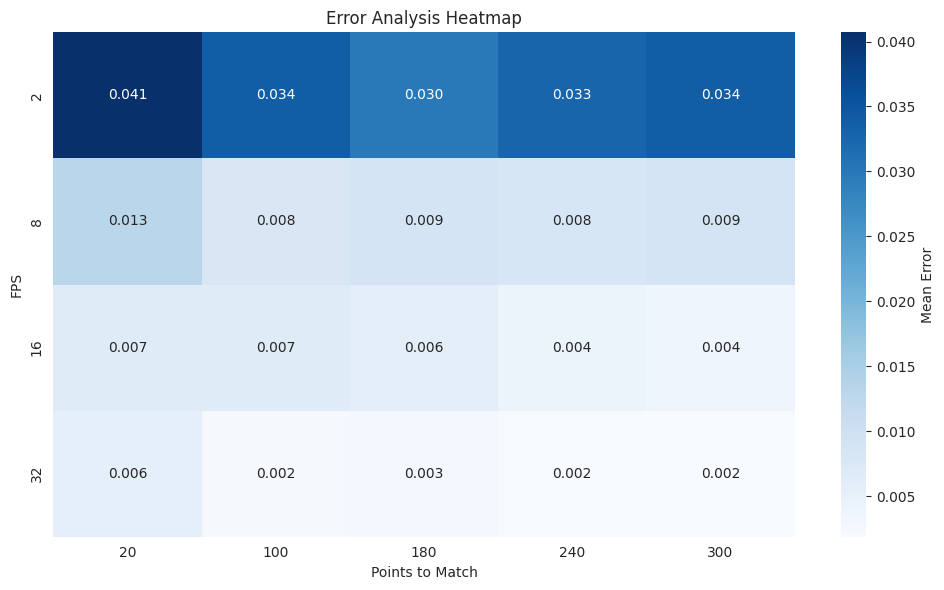

In [18]:
import os
import numpy as np
import json
import pandas as pd
# BUild a table of errors
errortable = {}
fps_values = [2, 8, 16, 32]
points_values = [20, 100, 180, 240, 300]
for FPS in fps_values:
    for POINTS_TO_MATCH in points_values:
        with open(f"synth_F_errors/{POINTS_TO_MATCH}_{FPS}.json", "r") as f:
            errors = json.load(f)
        errors = np.array(errors)
        # print(FPS, POINTS_TO_MATCH, np.mean(errors), np.std(errors))
        errortable[(FPS, POINTS_TO_MATCH)] = (np.mean(errors), np.std(errors))

mean_matrix = np.zeros((len(fps_values), len(points_values)))
for i, fps in enumerate(fps_values):
    for j, points in enumerate(points_values):
        mean_matrix[i, j] = errortable[(fps, points)][0]  # Get mean value from tuple

# Create the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(mean_matrix, 
            annot=True,  # Show values in cells
            fmt='.3f',   # Format for the annotations
            cmap='Blues',  # Color scheme
            xticklabels=points_values,
            yticklabels=fps_values,
            cbar_kws={'label': 'Mean Error'})

# Add labels and title
plt.xlabel('Points to Match')
plt.ylabel('FPS')
plt.title('Error Analysis Heatmap')

# Display the plot
plt.tight_layout()
plt.show()
